# EECS 6320 — Q3 Deliverable  
## Preprocessing + Baseline Bias (21st Mortgage Corporation)

**Implementing Q2 milestone** for the final project:
- Preprocess the 21st Mortgage Corporation data
- Train a **baseline Random Forest** model for `action_taken`
- Measure **baseline bias** before any debiasing
- Prepare a clean foundation for **Q3 debiasing methods**

### Q2 Objective
The goal is to **preprocess the dataset and find the baseline bias**. The project also assigns this responsibility to the preprocessing / baseline-model track.

### Modeling Choice
To make Q2 precise and reproducible, this notebook converts `action_taken` into a **binary approval task**:
- `1` → **Approved / originated**
- `3` → **Denied**

All other action codes are excluded from the Q2 baseline so that the fairness analysis is focused on a clean approval-vs-denial decision.

### Sensitive Attributes Used
Primary:
- `applicant_sex`
- `applicant_race_1`

Secondary:
- `applicant_age`

### Fairness Metrics Reported
- **Group Disparity Difference** (demographic parity gap / selection-rate gap)
- **Equal Opportunity Gap** (TPR gap)
- **False Positive Rate Gap**

---


In [4]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
from pathlib import Path
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.neighbors import NearestNeighbors

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# Set random seed
SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

In [5]:
# Mount Google Drive
drive.mount('/content/drive')

# Locate dataset automatically (works locally and in Colab)
candidate_paths = [
    Path("/mnt/data/21stMortgageCorporation_header.csv"),
    Path("./21stMortgageCorporation_header.csv"),
    Path("/content/21stMortgageCorporation_header.csv"),
    Path("/content/drive/MyDrive/EECS6320/Dataset/21stMortgageCorporation_header.csv"),
]

# Check all data paths to find applicable path to csv
DATA_PATH = None
for p in candidate_paths:
    if p.exists():
        DATA_PATH = p
        break

# If no path is found, raise error
if DATA_PATH is None:
    raise FileNotFoundError("21stMortgageCorporation_header.csv not found. Upload it or update candidate_paths.")

# Set an output directory for results
OUT_DIR = Path("/mnt/data/eecs6320_q2_outputs") if Path("/mnt/data").exists() else Path("./eecs6320_q2_outputs - oversampled")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Print input and output information
print(f"Using data file: {DATA_PATH}")
print(f"Saving outputs to: {OUT_DIR.resolve()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using data file: /content/drive/MyDrive/EECS6320/Dataset/21stMortgageCorporation_header.csv
Saving outputs to: /content/eecs6320_q2_outputs - oversampled


## 1) Define Q2 columns and target setup

The project draft already identifies a baseline feature subset.  
For Q2 we keep those baseline features, evaluate fairness on sex/race/age, and use `action_taken` as the target.


In [6]:
# Define the target column
TARGET_COL = "action_taken"

# Define numeric columns
BASELINE_NUMERIC_COLS = [
    "loan_amount",
    "income",
    "property_value",
    "loan_term",
]

# Define categorical columns
BASELINE_CATEGORICAL_COLS = [
    "occupancy_type",
    "state_code",
    "county_code",
    "applicant_credit_scoring_model",
    "debt_to_income_ratio",
    "interest_only_payment",
]

# Define sensitive attribute columns
SENSITIVE_COLS = [
    "applicant_sex",
    "applicant_race_1",
    "applicant_age",
]

# Combine all columns
ALL_REQUIRED_COLS = BASELINE_NUMERIC_COLS + BASELINE_CATEGORICAL_COLS + SENSITIVE_COLS + [TARGET_COL]

# Print all columns
ALL_REQUIRED_COLS

['loan_amount',
 'income',
 'property_value',
 'loan_term',
 'occupancy_type',
 'state_code',
 'county_code',
 'applicant_credit_scoring_model',
 'debt_to_income_ratio',
 'interest_only_payment',
 'applicant_sex',
 'applicant_race_1',
 'applicant_age',
 'action_taken']

In [7]:
# Read only required columns.
# IMPORTANT: the uploaded 21st Mortgage Corporation file is pipe-delimited, not comma-delimited.
raw_df = pd.read_csv(DATA_PATH, sep="|", usecols=ALL_REQUIRED_COLS, dtype="string")

# Print dataframe statistics and header
print("Raw shape:", raw_df.shape)
raw_df.head()

Raw shape: (163986, 14)


,occupancy_type,loan_amount,action_taken,state_code,county_code,applicant_race_1,applicant_sex,applicant_age,income,applicant_credit_scoring_model,debt_to_income_ratio,loan_term,interest_only_payment,property_value
0,1,105000,3,LA,22031,5,1,25-34,<NA>,9,<NA>,276,2,<NA>
1,1,55000,6,SC,45035,7,4,8888,<NA>,9,<NA>,180,2,55000
2,1,55000,6,NC,37081,7,4,8888,<NA>,9,<NA>,180,2,55000
3,1,45000,6,NC,37183,7,4,8888,<NA>,9,<NA>,144,2,45000
4,1,35000,6,TX,48121,7,4,8888,<NA>,9,<NA>,120,2,35000


## 2) Clean the raw data

Cleaning steps:
1. Replace `?` and blank strings with missing values.
2. Trim whitespace.
3. Keep only the valid Q2 target classes (`1` = approved, `3` = denied).
4. Keep valid sensitive attribute categories:
   - sex: `1`, `2`
   - race: `2`, `3`, `5`  → Asian, Black, White
   - age: valid ordinal age buckets only
5. Convert numeric feature columns to numeric.
6. Create a binary target:
   - approved = 1
   - denied = 0


In [8]:
# Clean raw strings
df = raw_df.copy()
df = df.replace(["?", "<NA>", "NA", "N/A", "null", "None", ""], np.nan)
df = df.replace(r"^\s*$", np.nan, regex=True)

# For all columns, remove whitespace
for col in df.columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# Keep valid target values for a clean approval-vs-denial baseline
df = df[df[TARGET_COL].isin(["1", "3"])].copy()

# Keep valid sensitive-attribute categories used in the current project design
valid_ages = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]
df = df[df["applicant_sex"].isin(["1", "2"])].copy()
df = df[df["applicant_race_1"].isin(["2", "3", "5"])].copy()
df = df[df["applicant_age"].isin(valid_ages)].copy()

# Convert numeric baseline columns
for col in BASELINE_NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Binary target: 1=approved, 0=denied
df["target"] = df[TARGET_COL].map({"1": 1, "3": 0}).astype("int64")

# Cast categoricals explicitly
for col in BASELINE_CATEGORICAL_COLS + SENSITIVE_COLS:
    df[col] = df[col].astype("object")

# Force any lingering pandas NA to np.nan
df = df.replace({pd.NA: np.nan})

# Print preprocessing results
print("Filtered / cleaned shape:", df.shape)
print("\nTarget distribution (1=approved, 0=denied):")
print(df["target"].value_counts(dropna=False))
print("\nMissing values after filtering:")
print(df[ALL_REQUIRED_COLS].isna().sum().sort_values(ascending=False))

Filtered / cleaned shape: (85241, 15)

Target distribution (1=approved, 0=denied):
target
0    62986
1    22255
Name: count, dtype: int64

Missing values after filtering:
property_value                    1731
income                            1730
debt_to_income_ratio              1723
loan_amount                          0
occupancy_type                       0
loan_term                            0
state_code                           0
county_code                          0
applicant_credit_scoring_model       0
interest_only_payment                0
applicant_sex                        0
applicant_race_1                     0
applicant_age                        0
action_taken                         0
dtype: int64


In [9]:
# Save cleaned Q2 dataset for reproducibility
clean_q2_path = OUT_DIR / "q2_cleaned_dataset.csv"
df.to_csv(clean_q2_path, index=False)
print(f"Saved cleaned dataset to: {clean_q2_path}")

Saved cleaned dataset to: eecs6320_q2_outputs - oversampled/q2_cleaned_dataset.csv


## 3) Train/test split

Sensitive attributes are kept **for evaluation**.  
The baseline model itself uses only the baseline feature subset, so Q2 can evaluate fairness externally rather than baking protected attributes directly into the model.


In [10]:
# Define X, Y, and sensitive dataframe
X = df[BASELINE_NUMERIC_COLS + BASELINE_CATEGORICAL_COLS + SENSITIVE_COLS].copy()
y = df["target"].copy()

# Define the train/test split percentage
test_split = 0.25

# Create train and test splits for X, Y, and sensitive.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_split,
    random_state=SEED,
    stratify=y,
)

# Print train test split results
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).rename("proportion"))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).rename("proportion"))

Train shape: (63930, 13)
Test shape: (21311, 13)

Train target distribution:
target
0    0.738918
1    0.261082
Name: proportion, dtype: float64

Test target distribution:
target
0    0.738914
1    0.261086
Name: proportion, dtype: float64


In [11]:
# Combine X_train and y_train for easier filtering
train_df = X_train.copy()
train_df["target"] = y_train.values

OVERSAMPLE_COLS = {
    "applicant_sex":    "os_sex",
    "applicant_race_1": "os_race",
    "applicant_age":    "os_age",
}

for col in OVERSAMPLE_COLS:
    print(f"\n── {col} ──")
    group_counts = (
        train_df[train_df["target"] == 1]
        .groupby(col)
        .size()
        .sort_values(ascending=False)
    )
    print(f"Approved counts per group:\n{group_counts.to_string()}")

# ── Build each oversampled dataframe independently from clean train_df ──

oversampled_dfs = {}

for col, df_name in OVERSAMPLE_COLS.items():
    group_counts = (
        train_df[train_df["target"] == 1]
        .groupby(col)
        .size()
        .sort_values(ascending=False)
    )
    max_count     = group_counts.max()
    rows_to_add   = []

    for group, count in group_counts.items():
        num_to_add = max_count - count
        if num_to_add == 0:
            continue
        minority_pos_df = train_df[
            (train_df[col] == group) &
            (train_df["target"] == 1)
        ]
        oversampled = minority_pos_df.sample(n=num_to_add, replace=True, random_state=SEED)
        rows_to_add.append(oversampled)

    result = pd.concat([train_df] + rows_to_add, ignore_index=True)
    oversampled_dfs[df_name] = result

os_sex  = oversampled_dfs["os_sex"]
os_race = oversampled_dfs["os_race"]
os_age  = oversampled_dfs["os_age"]

for col, df_name in OVERSAMPLE_COLS.items():
    print(f"\n── {df_name} ({col}) ──")
    df = oversampled_dfs[df_name]
    group_counts_after = (
        df[df["target"] == 1]
        .groupby(col)
        .size()
        .sort_values(ascending=False)
    )
    print(f"Approved counts per group:\n{group_counts_after.to_string()}")
    print(f"Train size: {len(train_df)} → {len(df)}")


── applicant_sex ──
Approved counts per group:
applicant_sex
1    9426
2    7265

── applicant_race_1 ──
Approved counts per group:
applicant_race_1
5    14424
3     2094
2      173

── applicant_age ──
Approved counts per group:
applicant_age
25-34    4366
35-44    3519
45-54    2997
55-64    2528
<25      1676
65-74    1305
>74       300

── os_sex (applicant_sex) ──
Approved counts per group:
applicant_sex
1    9426
2    9426
Train size: 63930 → 66091

── os_race (applicant_race_1) ──
Approved counts per group:
applicant_race_1
2    14424
3    14424
5    14424
Train size: 63930 → 90511

── os_age (applicant_age) ──
Approved counts per group:
applicant_age
25-34    4366
35-44    4366
45-54    4366
55-64    4366
65-74    4366
<25      4366
>74      4366
Train size: 63930 → 77801


## 4) Preprocessing pipeline + baseline Random Forest

Why this pipeline is strong for Q2:
- numeric features are median-imputed,
- categorical features are mode-imputed and one-hot encoded,
- the train/test transformation is identical and reproducible,
- the model is a clean **baseline**, leaving debiasing work for Q3.


In [12]:
# Define all four training configurations: baseline + three oversampled
training_configs = {
    "baseline": (X_train, y_train),
    "os_sex":   (os_sex.drop(columns=["target"]),  os_sex["target"]),
    "os_race":  (os_race.drop(columns=["target"]), os_race["target"]),
    "os_age":   (os_age.drop(columns=["target"]),  os_age["target"]),
}

# Store trained models and predictions
trained_models     = {}
predictions        = {}

for name, (X_tr, y_tr) in training_configs.items():
    print(f"Training '{name}' model  (train size: {len(X_tr)})...")

    # Fresh preprocessor and model for each run to avoid state leakage
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]), BASELINE_NUMERIC_COLS),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]), BASELINE_CATEGORICAL_COLS),
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=400,
                min_samples_leaf=2,
                class_weight="balanced_subsample",
                random_state=SEED,
                n_jobs=-1,
            )),
        ]
    )

    model.fit(X_tr, y_tr)

    # All models are evaluated on the same untouched test set
    y_pred  = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    trained_models[name] = model
    predictions[name] = {"y_pred": y_pred, "y_score": y_score}

    print(f"  ✓ '{name}' trained successfully.\n")

print("All models trained. Access via trained_models['baseline'], trained_models['os_sex'], etc.")

Training 'baseline' model  (train size: 63930)...
  ✓ 'baseline' trained successfully.

Training 'os_sex' model  (train size: 66091)...
  ✓ 'os_sex' trained successfully.

Training 'os_race' model  (train size: 90511)...
  ✓ 'os_race' trained successfully.

Training 'os_age' model  (train size: 77801)...
  ✓ 'os_age' trained successfully.

All models trained. Access via trained_models['baseline'], trained_models['os_sex'], etc.


### 4.1) MLP baseline


## 5) Baseline predictive performance

These metrics answer the question:  
**Is the baseline model functioning properly before we even talk about debiasing?**


In [13]:
# Print comparison header
print(f"{'Metric':<25}" + "".join(f"{name:>15}" for name in predictions))
print("-" * (25 + 15 * len(predictions)))

# Compute and print scalar metrics side by side
metrics = {}
for name, preds in predictions.items():
    y_pred  = preds["y_pred"]
    y_score = preds["y_score"]
    metrics[name] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
    }

for metric in ["Accuracy", "Balanced Accuracy", "ROC-AUC"]:
    row = f"{metric:<25}"
    for name in predictions:
        row += f"{metrics[name][metric]:>15.4f}"
    print(row)

# Print classification reports side by side (precision, recall, f1 per class)
print("\nClassification Report:")
reports = {
    name: classification_report(y_test, predictions[name]["y_pred"], digits=4, output_dict=True)
    for name in predictions
}

report_rows = ["0 - precision", "0 - recall", "0 - f1-score",
               "1 - precision", "1 - recall", "1 - f1-score",
               "macro avg - f1-score"]

print(f"{'Metric':<25}" + "".join(f"{name:>15}" for name in predictions))
print("-" * (25 + 15 * len(predictions)))

for row_label in report_rows:
    cls, metric = row_label.split(" - ")
    row = f"{row_label:<25}"
    for name in predictions:
        row += f"{reports[name][cls][metric]:>15.4f}"
    print(row)

Metric                          baseline         os_sex        os_race         os_age
-------------------------------------------------------------------------------------
Accuracy                          0.7966         0.7972         0.8083         0.8036
Balanced Accuracy                 0.8260         0.8250         0.8015         0.8281
ROC-AUC                           0.8893         0.8899         0.8824         0.8929

Classification Report:
Metric                          baseline         os_sex        os_race         os_age
-------------------------------------------------------------------------------------
0 - precision                     0.9506         0.9489         0.9157         0.9479
0 - recall                        0.7644         0.7669         0.8156         0.7769
0 - f1-score                      0.8474         0.8482         0.8628         0.8539
1 - precision                     0.5710         0.5724         0.6015         0.5820
1 - recall                    

## 6) Build fairness evaluation table

This evaluation frame keeps:
- sensitive attributes,
- true labels,
- predicted labels,
- predicted approval probability.


In [14]:
# Create a evaluation dataframe
eval_df = X_test[SENSITIVE_COLS].copy()
eval_df["y_true"] = y_test.to_numpy()
eval_df["y_pred"]  = predictions["baseline"]["y_pred"]
eval_df["y_score"] = predictions["baseline"]["y_score"]

# Mapping for sex and race
sex_map = {"1": "Male", "2": "Female"}
race_map = {"2": "Asian", "3": "Black", "5": "White"}

# Add labels that map applicant sex and race
eval_df["sex_label"] = eval_df["applicant_sex"].map(sex_map)
eval_df["race_label"] = eval_df["applicant_race_1"].map(race_map)

# Display evaluation dataframe header
eval_df.head()

,applicant_sex,applicant_race_1,applicant_age,y_true,y_pred,y_score,sex_label,race_label
107761,1,5,25-34,0,0,0.325531,Male,White
68500,2,5,35-44,0,0,0.059441,Female,White
65752,2,3,35-44,0,0,0.062031,Female,Black
70072,1,5,25-34,0,0,0.239198,Male,White
113531,1,5,55-64,0,1,0.776289,Male,White


## 7) Fairness metrics

For each group we compute:
- **Base positive rate** = actual approval rate in the test set
- **Selection rate** = predicted approval rate
- **True positive rate** = equal opportunity measure
- **False positive rate**

Then we summarize:
- **Demographic parity gap** = max selection rate − min selection rate
- **Equal opportunity gap** = max TPR − min TPR
- **FPR gap** = max FPR − min FPR


In [15]:
# Define the fairness table
def fairness_table(input_df, group_col, positive_label=1):
    rows = []

    for group_value, gdf in input_df.groupby(group_col):
        if pd.isna(group_value) or len(gdf) == 0:
            continue

        positive_true = (gdf["y_true"] == positive_label).sum()
        negative_true = (gdf["y_true"] != positive_label).sum()

        selection_rate = float((gdf["y_pred"] == positive_label).mean())
        base_positive_rate = float((gdf["y_true"] == positive_label).mean())

        tpr = np.nan
        if positive_true > 0:
            tpr = float(((gdf["y_pred"] == positive_label) & (gdf["y_true"] == positive_label)).sum() / positive_true)

        fpr = np.nan
        if negative_true > 0:
            fpr = float(((gdf["y_pred"] == positive_label) & (gdf["y_true"] != positive_label)).sum() / negative_true)

        rows.append({
            "group":              group_value,
            "n":                  int(len(gdf)),
            "base_positive_rate": base_positive_rate,
            "selection_rate":     selection_rate,
            "true_positive_rate": tpr,
            "false_positive_rate": fpr,
        })

    out = pd.DataFrame(rows).sort_values("group").reset_index(drop=True)
    overall_selection_rate = float((input_df["y_pred"] == positive_label).mean())
    out["selection_rate_minus_overall"] = out["selection_rate"] - overall_selection_rate
    return out

# Fairness metric summary
def fairness_gap_summary(tbl):
    return pd.Series({
        "demographic_parity_gap":  float(tbl["selection_rate"].max()      - tbl["selection_rate"].min()),
        "equal_opportunity_gap":   float(tbl["true_positive_rate"].max()  - tbl["true_positive_rate"].min()),
        "false_positive_rate_gap": float(tbl["false_positive_rate"].max() - tbl["false_positive_rate"].min()),
    })

# Build one eval_df per model, all using the same X_test base
sensitive_cols_config = {
    "sex":  ("sex_label",       "sex_label"),
    "race": ("race_label",      "race_label"),
    "age":  ("applicant_age",   "applicant_age"),
}

model_names = list(predictions.keys())  # ["baseline", "os_sex", "os_race", "os_age"]

# Build eval_df for each model
eval_dfs = {}
for name in model_names:
    edf = X_test[SENSITIVE_COLS].copy()
    edf["y_true"]    = y_test.to_numpy()
    edf["y_pred"]    = predictions[name]["y_pred"]
    edf["y_score"]   = predictions[name]["y_score"]
    edf["sex_label"] = edf["applicant_sex"].map({"1": "Male", "2": "Female"})
    edf["race_label"] = edf["applicant_race_1"].map({"2": "Asian", "3": "Black", "5": "White"})
    eval_dfs[name] = edf

# For each sensitive attribute, print fairness tables and gap summaries side by side
for attr, (group_col, display_col) in sensitive_cols_config.items():
    print("=" * 70)
    print(f"  FAIRNESS ANALYSIS — {attr.upper()}")
    print("=" * 70)

    # ── Per-model fairness tables ──
    tables = {name: fairness_table(eval_dfs[name], group_col) for name in model_names}

    for name in model_names:
        print(f"\n  [{name}] fairness table:")
        display(tables[name])

    # ── Gap summaries side by side ──
    gap_summaries = {name: fairness_gap_summary(tables[name]) for name in model_names}
    gap_df = pd.DataFrame(gap_summaries)
    print(f"\n  Gap summary comparison:")
    display(gap_df)

  FAIRNESS ANALYSIS — SEX

  [baseline] fairness table:


,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Female,11246,0.217677,0.365463,0.880310,0.222210,-0.040383
1,Male,10065,0.309588,0.450969,0.893453,0.252554,0.045122



  [os_sex] fairness table:


,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Female,11246,0.217677,0.363685,0.875000,0.221414,-0.039159
1,Male,10065,0.309588,0.446597,0.889602,0.247949,0.043754



  [os_race] fairness table:


...

,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,25-34,6117,0.235736,0.339382,0.820388,0.191016,-0.002413
1,35-44,4984,0.235955,0.350120,0.832483,0.201155,0.008325
2,45-54,3678,0.277325,0.350734,0.808824,0.174944,0.008939
3,55-64,2618,0.332697,0.386173,0.803674,0.178019,0.044377
4,65-74,1211,0.337737,0.259290,0.503667,0.134663,-0.082505
5,<25,2327,0.236356,0.327031,0.787273,0.184581,-0.014765
6,>74,376,0.255319,0.231383,0.572917,0.114286,-0.110412



  [os_age] fairness table:


,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,25-34,6117,0.235736,0.371424,0.877254,0.215401,-0.022973
1,35-44,4984,0.235955,0.383628,0.885204,0.228729,-0.010770
2,45-54,3678,0.277325,0.387167,0.868627,0.202408,-0.007230
3,55-64,2618,0.332697,0.436975,0.863375,0.224385,0.042578
4,65-74,1211,0.337737,0.535921,0.938875,0.330424,0.141523
5,<25,2327,0.236356,0.359691,0.860000,0.204840,-0.034707
6,>74,376,0.255319,0.444149,0.947917,0.271429,0.049752



  Gap summary comparison:


,baseline,os_sex,os_race,os_age
demographic_parity_gap,0.098516,0.103807,0.154790,0.176230
equal_opportunity_gap,0.163068,0.140225,0.328816,0.087917
false_positive_rate_gap,0.070746,0.072111,0.086870,0.128016


## 8) Visual summary

A quick visual summary for Q2:
- sex-based predicted approval rates,
- race-based predicted approval rates,
- age-based predicted approval rates.


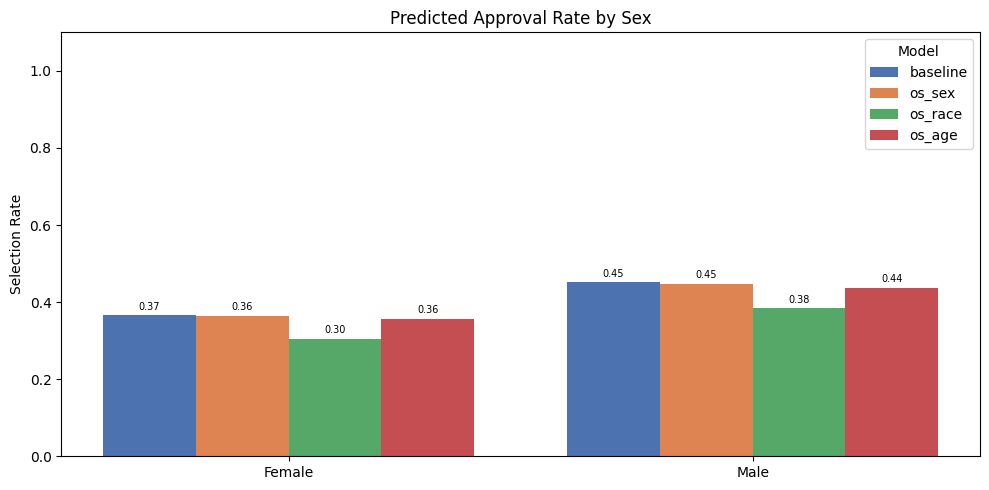

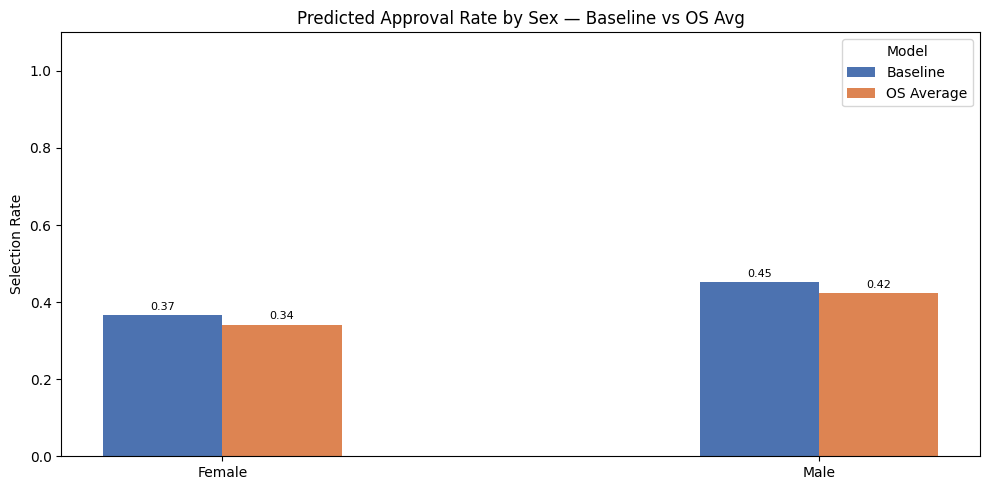

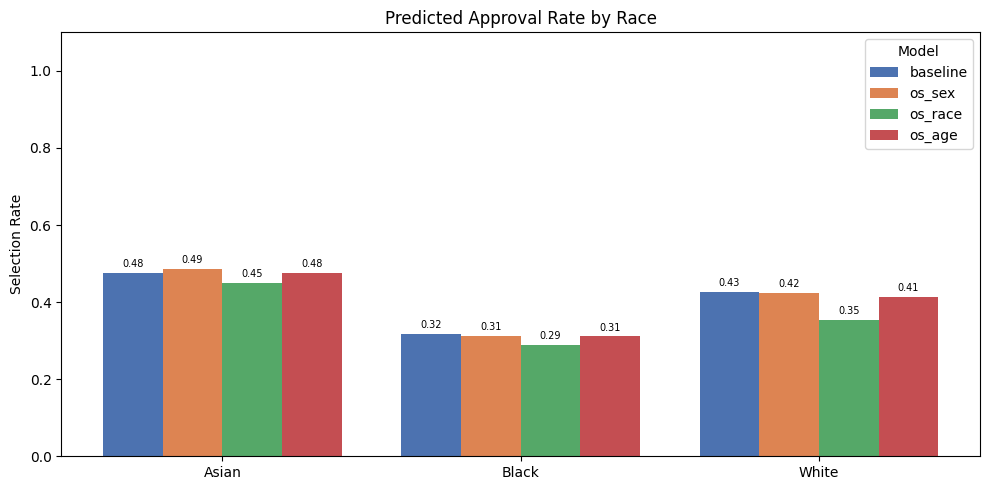

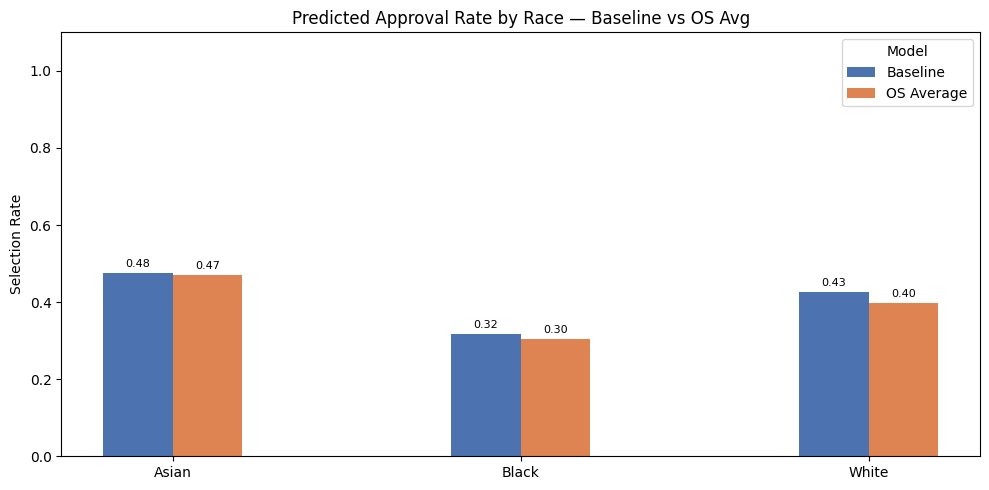

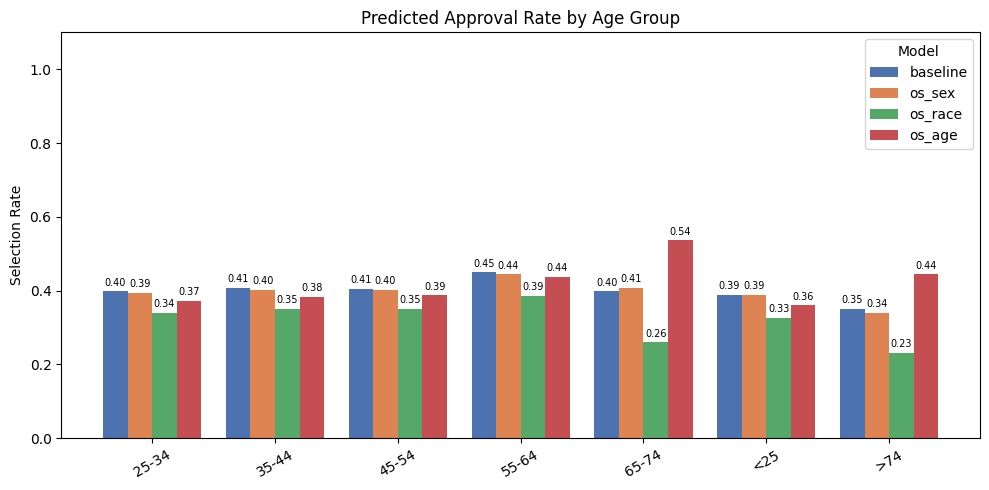

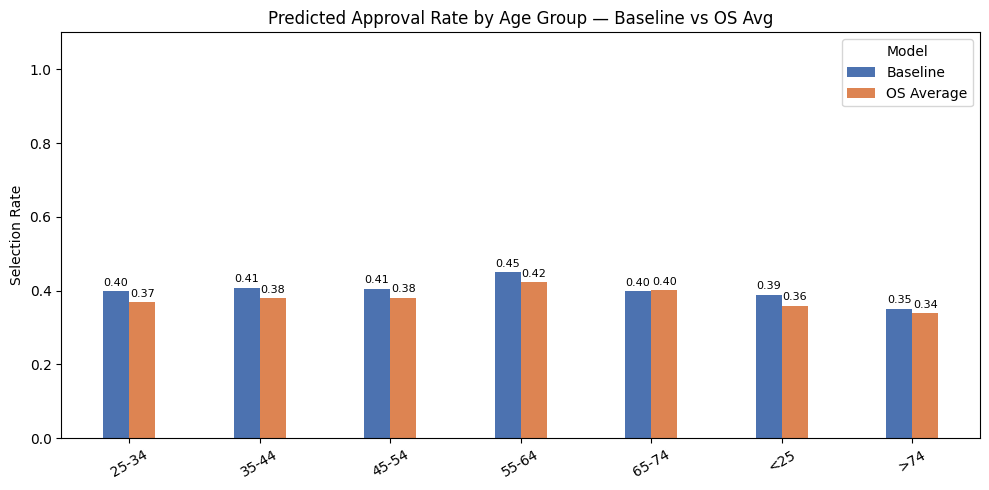

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

bar_width  = 0.2
colors     = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
output_dir = Path("charts")
output_dir.mkdir(exist_ok=True)

chart_configs = [
    ("SEX",  "sex_label",      "Predicted Approval Rate by Sex",       False, "os_sex"),
    ("RACE", "race_label",     "Predicted Approval Rate by Race",      False, "os_race"),
    ("AGE",  "applicant_age",  "Predicted Approval Rate by Age Group", True,  "os_age"),
]

def add_bar_labels(ax, bars, rates, fontsize=7):
    for bar, rate in zip(bars, rates):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{rate:.2f}",
            ha="center", va="bottom", fontsize=fontsize
        )

def setup_ax(ax, title, groups, x, rotate):
    ax.set_title(title)
    ax.set_ylabel("Selection Rate")
    ax.set_ylim(0, 1.1)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=30 if rotate else 0)
    ax.legend(title="Model")

model_names = list(predictions.keys())

for attr, group_col, title, rotate, os_key in chart_configs:
    groups = fairness_table(eval_dfs["baseline"], group_col)["group"].tolist()
    x      = np.arange(len(groups))

    # --- Chart 1: all models ---
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, name in enumerate(model_names):
        rates  = fairness_table(eval_dfs[name], group_col).set_index("group").loc[groups, "selection_rate"].values
        offset = (i - len(model_names) / 2 + 0.5) * bar_width
        bars   = ax.bar(x + offset, rates, width=bar_width, label=name, color=colors[i])
        add_bar_labels(ax, bars, rates)
    setup_ax(ax, title, groups, x, rotate)
    plt.tight_layout()
    fig.savefig(output_dir / f"{attr}_all_models.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- Chart 2: baseline vs averaged os_ models ---
    os_keys        = [k for k in eval_dfs if k in {"os_sex", "os_race", "os_age"}]
    baseline_rates = fairness_table(eval_dfs["baseline"], group_col).set_index("group").loc[groups, "selection_rate"].values
    os_avg_rates   = np.mean(
        [fairness_table(eval_dfs[k], group_col).set_index("group").loc[groups, "selection_rate"].values for k in os_keys],
        axis=0
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (label, rates) in enumerate([("Baseline", baseline_rates), ("OS Average", os_avg_rates)]):
        offset = (i - 1 + 0.5) * bar_width
        bars   = ax.bar(x + offset, rates, width=bar_width, label=label, color=colors[i])
        add_bar_labels(ax, bars, rates, fontsize=8)
    setup_ax(ax, f"{title} — Baseline vs OS Avg", groups, x, rotate)
    plt.tight_layout()
    fig.savefig(output_dir / f"{attr}_baseline_vs_os_avg.png", dpi=150, bbox_inches="tight")
    plt.show()

## 9) Save Q2 result tables

Save the results for future reference.


In [17]:
# Output directory paths
sex_fairness_path  = OUT_DIR / "q2_fairness_by_sex.csv"
race_fairness_path = OUT_DIR / "q2_fairness_by_race.csv"
age_fairness_path  = OUT_DIR / "q2_fairness_by_age.csv"
metrics_path       = OUT_DIR / "q2_model_metrics.csv"

# Build combined fairness tables (one per attribute) across all models
attr_configs = [
    ("sex",  "sex_label",     sex_fairness_path),
    ("race", "race_label",    race_fairness_path),
    ("age",  "applicant_age", age_fairness_path),
]

for attr, group_col, path in attr_configs:
    combined = None
    for name in model_names:
        tbl = fairness_table(eval_dfs[name], group_col)
        if combined is None:
            combined = tbl[["group", "n", "base_positive_rate"]].copy()
        for metric in ["selection_rate", "true_positive_rate", "false_positive_rate", "selection_rate_minus_overall"]:
            combined[f"{metric}_{name}"] = tbl[metric].values
    combined.to_csv(path, index=False)

# Build combined metrics dataframe across all models
metric_rows = []
for name in model_names:
    y_pred  = predictions[name]["y_pred"]
    y_score = predictions[name]["y_score"]

    sex_tbl  = fairness_table(eval_dfs[name], "sex_label")
    race_tbl = fairness_table(eval_dfs[name], "race_label")
    age_tbl  = fairness_table(eval_dfs[name], "applicant_age")

    sex_gap  = fairness_gap_summary(sex_tbl)
    race_gap = fairness_gap_summary(race_tbl)
    age_gap  = fairness_gap_summary(age_tbl)

    metric_rows.append({
        "model":                        name,
        "accuracy":                     accuracy_score(y_test, y_pred),
        "balanced_accuracy":            balanced_accuracy_score(y_test, y_pred),
        "roc_auc":                      roc_auc_score(y_test, y_score),
        "sex_demographic_parity_gap":   float(sex_gap["demographic_parity_gap"]),
        "sex_equal_opportunity_gap":    float(sex_gap["equal_opportunity_gap"]),
        "sex_fpr_gap":                  float(sex_gap["false_positive_rate_gap"]),
        "race_demographic_parity_gap":  float(race_gap["demographic_parity_gap"]),
        "race_equal_opportunity_gap":   float(race_gap["equal_opportunity_gap"]),
        "race_fpr_gap":                 float(race_gap["false_positive_rate_gap"]),
        "age_demographic_parity_gap":   float(age_gap["demographic_parity_gap"]),
        "age_equal_opportunity_gap":    float(age_gap["equal_opportunity_gap"]),
        "age_fpr_gap":                  float(age_gap["false_positive_rate_gap"]),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(metrics_path, index=False)

# Print successful saves
print("Saved:")
print(" -", sex_fairness_path)
print(" -", race_fairness_path)
print(" -", age_fairness_path)
print(" -", metrics_path)

Saved:
 - eecs6320_q2_outputs - oversampled/q2_fairness_by_sex.csv
 - eecs6320_q2_outputs - oversampled/q2_fairness_by_race.csv
 - eecs6320_q2_outputs - oversampled/q2_fairness_by_age.csv
 - eecs6320_q2_outputs - oversampled/q2_model_metrics.csv


## 10) Q2 conclusion

We reached the **Q2 milestone**:

- The 21st Mortgage Corporation dataset was cleaned and filtered for a approval-vs-denial task,
- A baseline Random Forest model was trained,
- Predictive metrics were reported,
- Baseline fairness was measured across **sex**, **race**, and **age**,
- The outputs were saved so that **Q3 debiasing methods** can be compared directly against this baseline.

